In [12]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/aman2525/uwoc-520k/UWOC_520k_Dataset.csv


In [13]:
df = pd.read_csv('/kaggle/input/datasets/aman2525/uwoc-520k/UWOC_520k_Dataset.csv')

In [14]:
df.head()

,Feature_I,Feature_Q,Feature_Mag,Feature_Phase,ROP_Level,Label
0,0.000397,0.000175,0.000434,0.415834,-28.0,13
1,0.000440,-0.001364,0.001434,-1.259003,-28.0,14
2,-0.001545,-0.001472,0.002134,-2.380308,-28.0,2
3,0.000424,-0.001274,0.001342,-1.249706,-28.0,14
4,0.001418,-0.001341,0.001952,-0.757286,-28.0,10


In [15]:
print("\n--- Summary Statistics ---")
print(df[['Feature_I', 'Feature_Q', 'Feature_Mag', 'Feature_Phase', 'ROP_Level']].describe())


--- Summary Statistics ---
           Feature_I     Feature_Q    Feature_Mag  Feature_Phase     ROP_Level
count  520000.000000  5.200000e+05  520000.000000  520000.000000  520000.00000
mean        0.000004 -1.868643e-06       0.001747       0.001528     -25.00000
std         0.001405  1.402300e-03       0.000942       1.797315       1.87083
min        -0.010017 -8.120899e-03       0.000008      -3.141539     -28.00000
25%        -0.000965 -9.662617e-04       0.001050      -1.553556     -26.50000
50%         0.000007 -8.667807e-07       0.001601      -0.002008     -25.00000
75%         0.000971  9.634652e-04       0.002266       1.571140     -23.50000
max         0.008770  7.525947e-03       0.012734       3.141537     -22.00000


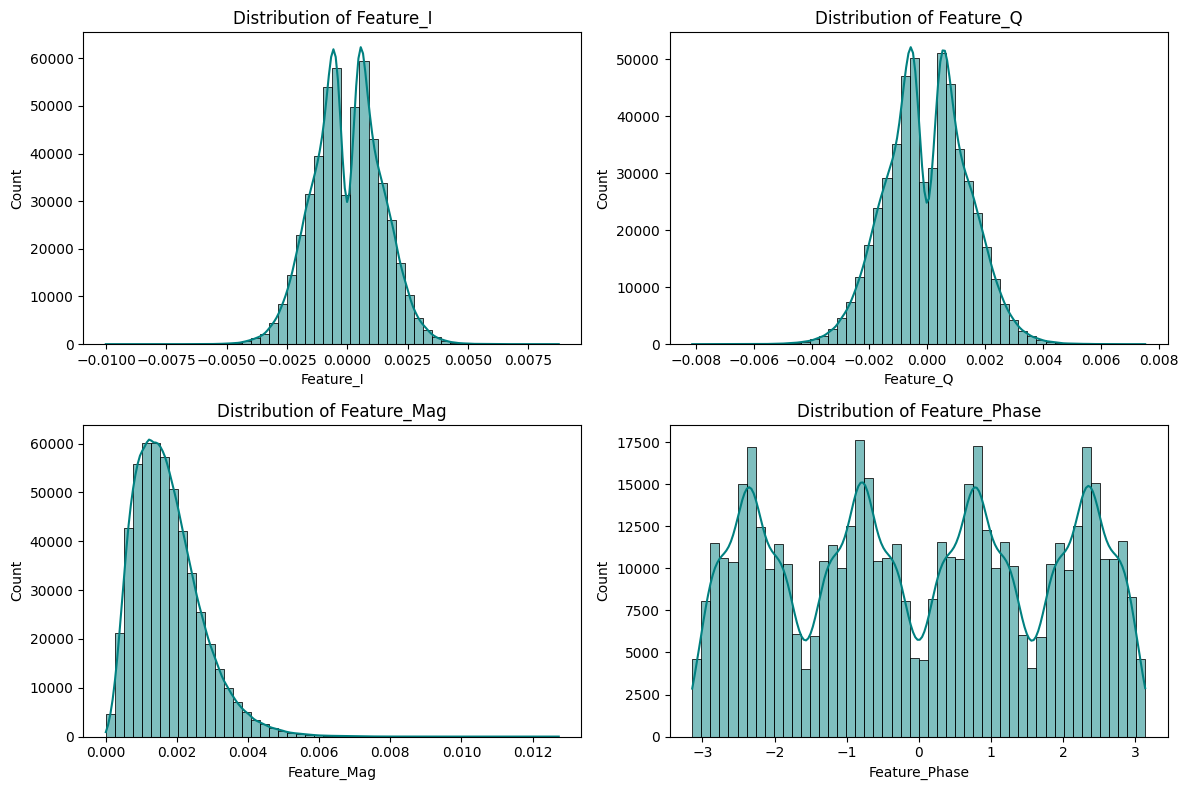

In [16]:
# --- VISUALIZATION 1: Feature Distributions ---
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 8))
for i, col in enumerate(['Feature_I', 'Feature_Q', 'Feature_Mag', 'Feature_Phase']):
    plt.subplot(2, 2, i+1)
    sns.histplot(df[col], bins=50, kde=True, color='teal')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

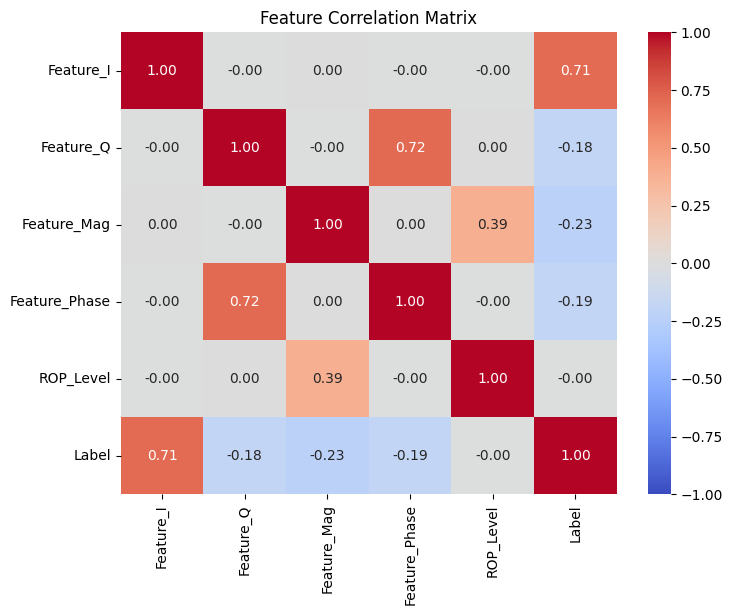

In [17]:
# --- VISUALIZATION 2: Correlation Heatmap ---
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Feature Correlation Matrix")
plt.show()

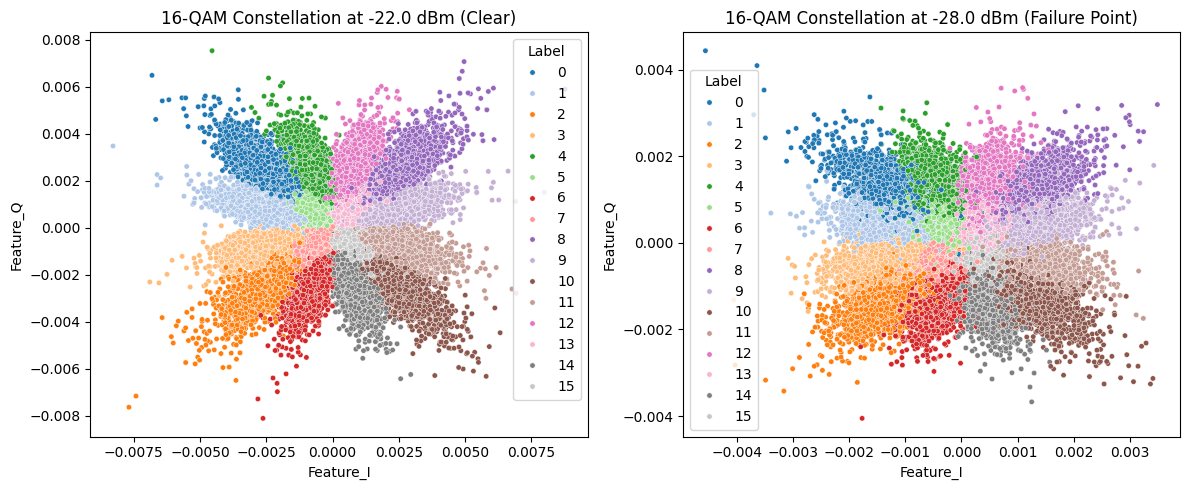

In [18]:
# --- VISUALIZATION 3: The Constellation Diagram ---
plt.figure(figsize=(12, 5))

# High Power (Clear Water)
plt.subplot(1, 2, 1)
high_power = df[df['ROP_Level'] == df['ROP_Level'].max()]
sns.scatterplot(x='Feature_I', y='Feature_Q', hue='Label', palette='tab20', data=high_power, legend=True, s=15)
plt.title(f'16-QAM Constellation at {df["ROP_Level"].max()} dBm (Clear)')

# Low Power (Turbid Water)
plt.subplot(1, 2, 2)
low_power = df[df['ROP_Level'] == df['ROP_Level'].min()]
sns.scatterplot(x='Feature_I', y='Feature_Q', hue='Label', palette='tab20', data=low_power, legend=True, s=15)
plt.title(f'16-QAM Constellation at {df["ROP_Level"].min()} dBm (Failure Point)')

plt.tight_layout()
plt.show()

In [19]:
# --- ROP LEVEL DISTRIBUTION ANALYSIS ---
print("\n--- ROP Level Distribution ---")

num_rop_levels = df['ROP_Level'].nunique()
print(f"Total Unique ROP Levels: {num_rop_levels}")

rop_counts = df['ROP_Level'].value_counts().sort_index(ascending=False)
print("\nNumber of rows per ROP Level:")
print(rop_counts)



--- ROP Level Distribution ---
Total Unique ROP Levels: 13

Number of rows per ROP Level:
ROP_Level
-22.0    40000
-22.5    40000
-23.0    40000
-23.5    40000
-24.0    40000
-24.5    40000
-25.0    40000
-25.5    40000
-26.0    40000
-26.5    40000
-27.0    40000
-27.5    40000
-28.0    40000
Name: count, dtype: int64


In [20]:
print("\n--- Engineering Required Telecommunication Features ---")
# 1. Symbol Energy (Solves amplitude fading)
df['Symbol_Energy'] = (df['Feature_I']**2) + (df['Feature_Q']**2)

# 2. Quadrant Indicator (Solves center-axis crossing errors)
df['I_Q_Product'] = df['Feature_I'] * df['Feature_Q']

# 3. Turbulence Indicator (Isolates severe phase rotations)
df['Phase_Mag_Ratio'] = df['Feature_Phase'] / (df['Feature_Mag'] + 1e-6)

base_cols = ['Feature_I', 'Feature_Q', 'Feature_Mag', 'Feature_Phase', 'ROP_Level']
all_cols = base_cols + ['Symbol_Energy', 'I_Q_Product', 'Phase_Mag_Ratio']

X = df[all_cols]
y = df['Label']
worst_rop = df['ROP_Level'].min()


--- Engineering Required Telecommunication Features ---


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ===================== TRAIN TEST SPLIT =====================
print("--- Splitting Data ---")
stratify_col = df['ROP_Level'].astype(str) + "_" + df['Label'].astype(str)

# Strictly keeping shuffle=True for proper randomization
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True, stratify=stratify_col
)

# Scale all features
scaler = StandardScaler()
X_train_s_df = pd.DataFrame(scaler.fit_transform(X_train), columns=all_cols)
X_test_s_df = pd.DataFrame(scaler.transform(X_test), columns=all_cols)

# We need the unscaled ROP level for masking during testing
rop_test_unscaled = X_test['ROP_Level'].values
mask_worst = (rop_test_unscaled == worst_rop)

--- Splitting Data ---


In [24]:
# 4. PART A: THE ALGORITHM SHOWDOWN (Using all 8 features)



from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import LinearSVC, SVC
from sklearn.metrics import accuracy_score



# ===================== STEP 1: RAW BASELINE SHOWDOWN =====================
print("\n=======================================================")
print("  STEP 1: ALGORITHM SHOWDOWN (RAW BASELINE FEATURES ONLY)")
print("=======================================================")

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
    "Linear SVM": LinearSVC(max_iter=1000, random_state=42),
    "Gradient Boosting": HistGradientBoostingClassifier(max_iter=100, random_state=42),
    "RBF SVM (Subset)": SVC(kernel='rbf', max_iter=2000, random_state=42),
    "KNN (Base Feature Baseline)": KNeighborsClassifier(n_neighbors=7, n_jobs=-1),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Gaussian Naive Bayes": GaussianNB()
}

showdown_results = []

for name, model in models.items():
    if "RBF SVM" in name:
        subset_size = min(10000, X_train_s_df.shape[0])
        idx = np.random.choice(X_train_s_df.shape[0], subset_size, replace=False)
        model.fit(X_train_s_df[base_cols].iloc[idx], y_train.values[idx])
    else:
        model.fit(X_train_s_df[base_cols], y_train)

    preds = model.predict(X_test_s_df[base_cols])
    acc_all = accuracy_score(y_test, preds) * 100
    acc_worst = accuracy_score(y_test[mask_worst], preds[mask_worst]) * 100

    showdown_results.append({"Algorithm": name, "Overall Acc (%)": round(acc_all, 2), f"Acc at {worst_rop} dBm (%)": round(acc_worst, 2)})

showdown_df = pd.DataFrame(showdown_results).sort_values(by=f"Acc at {worst_rop} dBm (%)", ascending=False)
print(showdown_df.to_string(index=False))


  STEP 1: ALGORITHM SHOWDOWN (RAW BASELINE FEATURES ONLY)
                  Algorithm  Overall Acc (%)  Acc at -28.0 dBm (%)
          Gradient Boosting            82.76                 71.63
        Logistic Regression            82.92                 71.57
                 Linear SVM            82.69                 71.27
           RBF SVM (Subset)            82.58                 71.04
KNN (Base Feature Baseline)            81.28                 69.12
              Random Forest            80.96                 68.78
              Decision Tree            74.88                 60.33
       Gaussian Naive Bayes            77.37                 59.48


In [25]:
print("\n=======================================================")
print("  STEP 2: FEATURE ABLATION (ON LOGISTIC REGRESSION)")
print("=======================================================")

# Testing which features actually improve the linear boundaries
feature_stages = {
    "1. Baseline (5 Raw)": base_cols,
    "2. Baseline + Energy": base_cols + ['Symbol_Energy'],
    "3. Baseline + Energy + I_Q_Product": base_cols + ['Symbol_Energy', 'I_Q_Product'],
    "4. All Features": all_cols
}

ablation_results = []
# Using Logistic Regression as the transparent "physics lie detector"
ablation_model = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)

for stage_name, cols in feature_stages.items():
    ablation_model.fit(X_train_s_df[cols], y_train)
    preds = ablation_model.predict(X_test_s_df[cols])
    acc_worst = accuracy_score(y_test[mask_worst], preds[mask_worst]) * 100
    ablation_results.append({"Feature Set": stage_name, f"Acc at {worst_rop} dBm (%)": round(acc_worst, 2)})

print(pd.DataFrame(ablation_results).to_string(index=False))


  STEP 2: FEATURE ABLATION (ON LOGISTIC REGRESSION)
                       Feature Set  Acc at -28.0 dBm (%)
               1. Baseline (5 Raw)                 71.57
              2. Baseline + Energy                 71.69
3. Baseline + Energy + I_Q_Product                 71.71
                   4. All Features                 71.68


In [27]:
# ===================== STEP 3: NEW DATASET VALIDATION =====================
print("\n=======================================================")
print("  STEP 3: TOP MODELS VALIDATION ON OPTIMAL FEATURES")
print("=======================================================")

from sklearn.model_selection import GridSearchCV

# Locking in the proven optimal feature set based on Step 2 results!
best_cols = base_cols + ['Symbol_Energy', 'I_Q_Product']

top_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
    "Gradient Boosting": HistGradientBoostingClassifier(max_iter=100, random_state=42),
    "Linear SVM": LinearSVC(max_iter=1000, random_state=42),
    "KNN (Fair Comparison)": KNeighborsClassifier(n_neighbors=7, n_jobs=-1)
}

val_results = []
for name, model in top_models.items():
    model.fit(X_train_s_df[best_cols], y_train)
    preds = model.predict(X_test_s_df[best_cols])
    acc_worst = accuracy_score(y_test[mask_worst], preds[mask_worst]) * 100
    val_results.append({"Algorithm": name, f"Acc at {worst_rop} dBm (Optimal Features) (%)": round(acc_worst, 2)})

print(pd.DataFrame(val_results).sort_values(by=f"Acc at {worst_rop} dBm (Optimal Features) (%)", ascending=False).to_string(index=False))


# ===================== STEP 4: HYPERPARAMETER TUNING =====================
print("\n=======================================================")
print("  STEP 4: HYPERPARAMETER TUNING (TOP 3 + KNN)")
print("=======================================================")

# 1. Tune Logistic Regression
print("Tuning Logistic Regression...")
param_grid_lr = {'C': [0.1, 1, 10]}
grid_lr = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42), param_grid_lr, cv=3, scoring='accuracy', n_jobs=-1)
grid_lr.fit(X_train_s_df[best_cols], y_train)
best_lr = grid_lr.best_estimator_

# 2. Tune Gradient Boosting
print("Tuning Gradient Boosting...")
param_grid_gb = {'learning_rate': [0.05, 0.1], 'max_depth': [3, 5]}
grid_gb = GridSearchCV(HistGradientBoostingClassifier(random_state=42), param_grid_gb, cv=3, scoring='accuracy', n_jobs=-1)
grid_gb.fit(X_train_s_df[best_cols], y_train)
best_gb = grid_gb.best_estimator_

# 3. Tune Linear SVM
print("Tuning Linear SVM...")
param_grid_svm = {'C': [0.1, 1, 10]}
grid_svm = GridSearchCV(LinearSVC(max_iter=1000, random_state=42), param_grid_svm, cv=3, scoring='accuracy', n_jobs=-1)
grid_svm.fit(X_train_s_df[best_cols], y_train)
best_svm = grid_svm.best_estimator_

# 4. Tune KNN
print("Tuning KNN (Baseline)...")
param_grid_knn = {'n_neighbors': [5, 7, 9], 'weights': ['uniform', 'distance']}
grid_knn = GridSearchCV(KNeighborsClassifier(n_jobs=-1), param_grid_knn, cv=3, scoring='accuracy', n_jobs=-1)
grid_knn.fit(X_train_s_df[best_cols], y_train)
best_knn = grid_knn.best_estimator_

print("\n--- TUNED PERFORMANCE @ -28 dBm ---")
for name, model in zip(["Logistic Regression", "Gradient Boosting", "Linear SVM", "KNN"], 
                       [best_lr, best_gb, best_svm, best_knn]):
    acc = accuracy_score(y_test[mask_worst], model.predict(X_test_s_df[best_cols][mask_worst])) * 100
    print(f"{name}: {acc:.2f}%")


  STEP 3: TOP MODELS VALIDATION ON OPTIMAL FEATURES
            Algorithm  Acc at -28.0 dBm (Optimal Features) (%)
    Gradient Boosting                                    71.86
  Logistic Regression                                    71.71
           Linear SVM                                    71.63
KNN (Fair Comparison)                                    68.99

  STEP 4: HYPERPARAMETER TUNING (TOP 3 + KNN)
Tuning Logistic Regression...
Tuning Gradient Boosting...
Tuning Linear SVM...
Tuning KNN (Baseline)...

--- TUNED PERFORMANCE @ -28 dBm ---
Logistic Regression: 71.71%
Gradient Boosting: 71.91%
Linear SVM: 71.63%
KNN: 69.82%


In [29]:
# ===================== PRINT FINAL TUNED RESULTS (OVERALL & -28 dBm) =====================
print("\n--- FINAL TUNED PERFORMANCE TABLE ---")

tuned_results = []
models_dict = {
    "Logistic Regression": best_lr,
    "Gradient Boosting": best_gb,
    "Linear SVM": best_svm,
    "KNN (Base Feature Baseline)": best_knn
}

for name, model in models_dict.items():
    # Predict on the ENTIRE test set
    preds_all = model.predict(X_test_s_df[best_cols])
    
    # Calculate overall accuracy
    overall_acc = accuracy_score(y_test, preds_all) * 100
    
    # Calculate worst-case accuracy (-28 dBm)
    worst_acc = accuracy_score(y_test[mask_worst], preds_all[mask_worst]) * 100
    
    tuned_results.append({
        "Algorithm": name, 
        "Overall Tuned Acc (%)": round(overall_acc, 2), 
        "Tuned Acc at -28 dBm (%)": round(worst_acc, 2)
    })

# Display as a clean, publication-ready table
final_tuned_df = pd.DataFrame(tuned_results).sort_values(by="Tuned Acc at -28 dBm (%)", ascending=False)
print(final_tuned_df.to_string(index=False))


--- FINAL TUNED PERFORMANCE TABLE ---
                  Algorithm  Overall Tuned Acc (%)  Tuned Acc at -28 dBm (%)
          Gradient Boosting                  82.86                     71.91
        Logistic Regression                  82.97                     71.71
                 Linear SVM                  82.76                     71.63
KNN (Base Feature Baseline)                  81.62                     69.82


In [33]:
print("\n--- Saving Tuned ML Results to CSV ---")

rop_levels = np.sort(X_test['ROP_Level'].unique())
acc_lr_list = []
acc_gb_list = []
acc_knn_list = []

# Evaluate the final tuned models at every ROP level
for r in rop_levels:
    mask_r = (rop_test_unscaled == r)
    
    # Logistic Regression (The Overall Champion)
    acc_lr_list.append(accuracy_score(y_test[mask_r], best_lr.predict(X_test_s_df[best_cols][mask_r])))
    
    # Gradient Boosting (The -28 dBm Champion)
    acc_gb_list.append(accuracy_score(y_test[mask_r], best_gb.predict(X_test_s_df[best_cols][mask_r])))
    
    # KNN (The Baseline Comparison)
    acc_knn_list.append(accuracy_score(y_test[mask_r], best_knn.predict(X_test_s_df[best_cols][mask_r])))

# Save to a DataFrame and export to CSV
export_df = pd.DataFrame({
    'ROP_Level': rop_levels,
    'KNN_Accuracy': acc_knn_list,
    'LR_Accuracy': acc_lr_list,
    'GB_Accuracy': acc_gb_list
})

export_df.to_csv('ML_Results_For_Graph.csv', index=False)
print("SUCCESS: Data saved to 'ML_Results_For_Graph.csv'.")
print("You can safely close this notebook. Your traditional ML pipeline is complete!")


--- Saving Tuned ML Results to CSV ---
SUCCESS: Data saved to 'ML_Results_For_Graph.csv'.
You can safely close this notebook. Your traditional ML pipeline is complete!
